In [8]:
import pandas as pd
import numpy as np

from market_data import MarketData
from data_processor import DataProcessor
from calculate_indicators import Calculate
from trading_strategy import TradingStrategy

# **1. Download Data**

In [9]:
tickers = [
    # Technology (Công nghệ)
    "AAPL","MSFT","GOOGL","AMZN","META",
    "NVDA","AMD","INTC","AVGO",
    "ADBE","CRM","ORCL","IBM",
    "SAP","ASML","QCOM","TXN",
    "UBER","SHOP","XYZ","NFLX","SONY",
    "INTU","ADSK","SNOW",

    # Financials (Tài chính – ngân hàng – đầu tư)
    "JPM","BAC","WFC","C",
    "GS","MS","BRK-A","BRK-B",
    "V","MA","PYPL","AXP",
    "SCHW","BLK","HSBC","RY",
    "CME","BK",

    # Consumer (Tiêu dùng – bán lẻ – giải trí)
    "WMT","COST","HD","TGT",
    "MCD","SBUX","KO","PEP",
    "PG","UL","DEO","PM",
    "NKE","DIS","CMG","TSM",
    "EA","TTWO","RBLX",
    "MGM","YUM",

    # Industrials (Công nghiệp – vận tải – quốc phòng)
    "CAT","DE","BA","LMT",
    "UPS","FDX","GE","HON",
    "MMM","RTX","NOC","GD",
    "EMR",

    # Energy & Materials (Năng lượng – nguyên vật liệu)
    "XOM","CVX","BP","SHEL",
    "COP","SLB","HAL","EOG",
    "LIN","APD","SHW","FCX","NUE",

    # Healthcare (Y tế – dược phẩm – bảo hiểm y tế)
    "JNJ","PFE","MRK","ABT","ABBV",
    "UNH","CVS","TMO","BMY","AMGN"
]

len(tickers)

100

In [10]:
market = MarketData(tickers)
market.download_data(start_date = "2010-01-01", end_date = "2025-10-11")

[*********************100%***********************]  100 of 100 completed


Price        Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2010-01-04    6.418382         NaN   18.414780   37.090000   25.670000   
2010-01-05    6.429478         NaN   18.266006   37.700001   25.280001   
2010-01-06    6.327210         NaN   18.367445   37.619999   25.340000   
2010-01-07    6.315514         NaN   18.519611   36.889999   25.480000   
2010-01-08    6.357501         NaN   18.614286   36.689999   26.260000   
...                ...         ...         ...         ...         ...   
2025-10-06  256.441406  228.542419  133.147934  350.140015  323.429993   
2025-10-07  256.231628  231.163513  132.431122  348.309998  314.190002   
2025-10-08  257.810089  229.584900  133.675583  348.769989  311.410004   
2025-10-09  253.793961  229.038834  132.719818  347.470001  310.320007   
2025-10-10  245.032471  228.850189  131.983109  337.510010  303.500000   

Price                                                                    ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2010-01-04    9.700000   39.311672    6.695000   51.808636    32.425724  ...   
2010-01-05    9.710000   38.971142    6.734500   51.378777    32.678322  ...   
2010-01-06    9.570000   38.678268    6.612500   50.955139    32.977692  ...   
2010-01-07    9.470000   38.324116    6.500000   50.662342    32.060871  ...   
2010-01-08    9.430000   38.664658    6.676000   50.986298    31.293718  ...   
...                ...         ...         ...         ...          ...  ...   
2025-10-06  203.710007  292.037079  220.899994  270.950012  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  270.890015  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  268.579987   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  262.709991   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  257.079987   934.531982  ...   

Price           Volume                                                   \
Ticker            UBER       UL       UNH       UPS         V       WFC   
Date                                                                      
2010-01-04         NaN   799200  12199500   3897200  20180000  39335700   
2010-01-05         NaN   929500  11180700   5966300  25833600  55416000   
2010-01-06         NaN  1811600   9761100   5770200  16254000  33237000   
2010-01-07         NaN  1365300  11789800   5747000  27841200  61649000   
2010-01-08         NaN   761700   7228700  13779300  11907200  35508700   
...                ...      ...       ...       ...       ...       ...   
2025-10-06  22760900.0  2028600   7181700   6987000   4735600  12837700   
2025-10-07  12583600.0  2186600   7236200   4726800   5044600  10371300   
2025-10-08  10071200.0  1821300   9438300   4896000   3927500  11277400   
2025-10-09  13435700.0  2520000   8759800   5784700   4434800   8432200   
2025-10-10  17021100.0  5310800  13141900   8506000   6296200  16004300   

Price                                               
Ticker           WMT       XOM        XYZ      YUM  
Date                                                
2010-01-04  62259300  27809100        NaN  2962274  
2010-01-05  46945200  30174700        NaN  3298757  
2010-01-06  37551600  35044700        NaN  4178981  
2010-01-07  31988100  27192100        NaN  2452472  
2010-01-08  34089600  24891800        NaN  3772392  
...              ...       ...        ...      ...  
2025-10-06  13303600  12036800  5324100.0  1395000  
2025-10-07  15538900  11945000  5428000.0  1657100  
2025-10-08  13584100  12301000  6024900.0  1150600  
2025-10-09  19508000  10976200  4193600.0  1371000  
2025-10-10  18519400  13811600  8802300.0  2055300  

[3968 rows x 600 columns]

In [11]:
market.save_df(filename='price_volume_data.csv')

# **2. Data Preparation and Outlier Handling**

In [ ]:
import os 
os.chdir(r"C:\Users\Admin\Downloads\scripts")
#os.chdir(r"C:\Users\Admin\Downloads")

In [ ]:
import pandas as pd
import numpy as np
from calculate_indicators import Calculate
from data_processor import DataProcessor

In [ ]:
os.chdir(r"C:\Users\Admin\Downloads")

In [2]:
data = pd.read_csv("price_volume_data.csv", header=[0, 1], index_col=0, parse_dates=True)
data.head()

Price      Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418382  NaN  18.414780  37.090000  25.670000  9.70  39.311672   
2010-01-05  6.429478  NaN  18.266006  37.700001  25.280001  9.71  38.971142   
2010-01-06  6.327210  NaN  18.367445  37.619999  25.340000  9.57  38.678268   
2010-01-07  6.315514  NaN  18.519611  36.889999  25.480000  9.47  38.324116   
2010-01-08  6.357501  NaN  18.614286  36.689999  26.260000  9.43  38.664658   

Price                                     ... Volume                     \
Ticker        AMZN        APD       ASML  ...   UBER       UL       UNH   
Date                                      ...                             
2010-01-04  6.6950  51.808636  32.425724  ...    NaN   799200  12199500   
2010-01-05  6.7345  51.378777  32.678322  ...    NaN   929500  11180700   
2010-01-06  6.6125  50.955139  32.977692  ...    NaN  1811600   9761100   
2010-01-07  6.5000  50.662342  32.060871  ...    NaN  1365300  11789800   
2010-01-08  6.6760  50.986298  31.293718  ...    NaN   761700   7228700   

Price                                                                      
Ticker           UPS         V       WFC       WMT       XOM XYZ      YUM  
Date                                                                       
2010-01-04   3897200  20180000  39335700  62259300  27809100 NaN  2962274  
2010-01-05   5966300  25833600  55416000  46945200  30174700 NaN  3298757  
2010-01-06   5770200  16254000  33237000  37551600  35044700 NaN  4178981  
2010-01-07   5747000  27841200  61649000  31988100  27192100 NaN  2452472  
2010-01-08  13779300  11907200  35508700  34089600  24891800 NaN  3772392  

[5 rows x 600 columns]

In [3]:
prepare = DataProcessor("price_volume_data.csv")

# for ticker in prepare.tickers:
#     prepare.check_na(ticker)

prepare.add_log_returns()

prepare.winsorize_data()

prepare.save_cleaned_data("cleaned_price_volume_data.csv")

# for ticker in tickers:
#     prepare.draw_boxplot(ticker, 'Return')

# for ticker in tickers:
#     prepare.draw_histogram(ticker, 'Return')

In [4]:
c = Calculate("cleaned_price_volume_data.csv")
c.add_indicators()

c.df.to_csv("price_volume_indicators_data.csv")

# c.calculate_position_size()

print(set(c.df.columns.get_level_values(0)))
c.df.tail()

{'Log Return', 'High', 'Adj Close', 'SMA_200', 'Close', 'Volume', 'Volatility', 'SMA_50', 'Open', 'Low'}


Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2025-10-06  256.441406  228.542419  133.147934  350.140015  323.429993   
2025-10-07  256.231628  231.163513  132.431122  348.309998  314.190002   
2025-10-08  257.810089  229.584900  133.675583  348.769989  311.410004   
2025-10-09  253.793961  229.038834  132.719818  347.470001  310.320007   
2025-10-10  245.032471  228.850189  131.983109  337.510010  303.500000   

                                                                         ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2025-10-06  203.710007  292.037079  220.899994  270.950012  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  270.890015  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  268.579987   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  262.709991   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  257.079987   934.531982  ...   

           Volatility                                                    \
Ticker           UBER        UL       UNH       UPS         V       WFC   
Date                                                                      
2025-10-06   0.330651  0.114899  0.216224  0.158889  0.187395  0.166190   
2025-10-07   0.323294  0.116156  0.215119  0.158124  0.188967  0.166795   
2025-10-08   0.324837  0.110913  0.207018  0.158309  0.189097  0.164778   
2025-10-09   0.344127  0.114522  0.208329  0.162004  0.183891  0.163711   
2025-10-10   0.357635  0.127833  0.219267  0.176753  0.179751  0.184610   

                                                    
Ticker           WMT       XOM       XYZ       YUM  
Date                                                
2025-10-06  0.132781  0.187287  0.329469  0.190732  
2025-10-07  0.120869  0.186948  0.331345  0.183113  
2025-10-08  0.121495  0.186435  0.340763  0.176204  
2025-10-09  0.111908  0.181956  0.327480  0.190402  
2025-10-10  0.094926  0.194233  0.390170  0.173572  

[5 rows x 1000 columns]

In [ ]:
import os
os.chdir('C:/Users/Admin/Downloads')

# **3. Trading Strategy**

In [1]:
from trading_strategy import TradingStrategy
from matplotlib import pyplot as plt
from plot import Plot

In [2]:
strategy = TradingStrategy("price_volume_indicators_data.csv")
print(set(strategy.df.columns.get_level_values(0)))

{'Log Return', 'Volume', 'Open', 'Close', 'SMA_50', 'SMA_200', 'High', 'Volatility', 'Adj Close', 'Low'}


## **3.1. Momentum Strategy**

In [3]:
strategy.momentum_signal()
strategy.apply_position_sizing()

In [4]:
print(set(strategy.df.columns.get_level_values(0)))

{'Log Return', 'Volume', 'Signal', 'Open', 'Close', 'SMA_50', 'SMA_200', 'High', 'Volatility', 'Adj Close', 'Low', 'Position Size'}


In [5]:
strategy.get_actions().sort_values(by=['Value_Est'], ascending=False).head(10)

Ngày giao dịch: 2025-10-10


,Ticker,Action,Shares,Price_Est,Value_Est
10,CME,BUY,54,268.839996,14517.359802
42,PEP,BUY,93,144.710007,13458.030624
61,UPS,SELL,147,83.822830,12321.956039
37,MMM,SELL,72,152.225906,10960.265259
3,AMZN,BUY,44,227.740005,10020.560242
5,BA,SELL,36,216.000000,7776.000000
14,CRM,BUY,31,245.330002,7605.230057
13,COST,BUY,1,941.557922,941.557922
62,WMT,BUY,8,101.769997,814.159973
27,HON,BUY,4,191.342178,765.368713


In [6]:
top_long, top_short = strategy.get_top_portfolio(top_n=10)
top_long

Ngày giao dịch: 2025-10-10


,Ticker,Price,Volatility,Action,Shares,Value
0,RY,143.639999,0.092477,LONG,79,11347.559952
1,BRK-B,489.130005,0.098613,LONG,21,10271.730103
3,WMT,101.839996,0.094926,LONG,87,8860.079681
6,JPM,300.890015,0.119291,LONG,27,8124.030396
9,LMT,501.244415,0.127377,LONG,15,7518.666229
10,BAC,48.650002,0.147086,LONG,150,7297.500229
11,JNJ,189.516724,0.131983,LONG,38,7201.635498
14,CME,271.450012,0.139318,LONG,26,7057.700317
15,BK,104.026932,0.153075,LONG,66,6865.777496
16,GD,332.940002,0.152090,LONG,20,6658.800049


In [ ]:
top_short

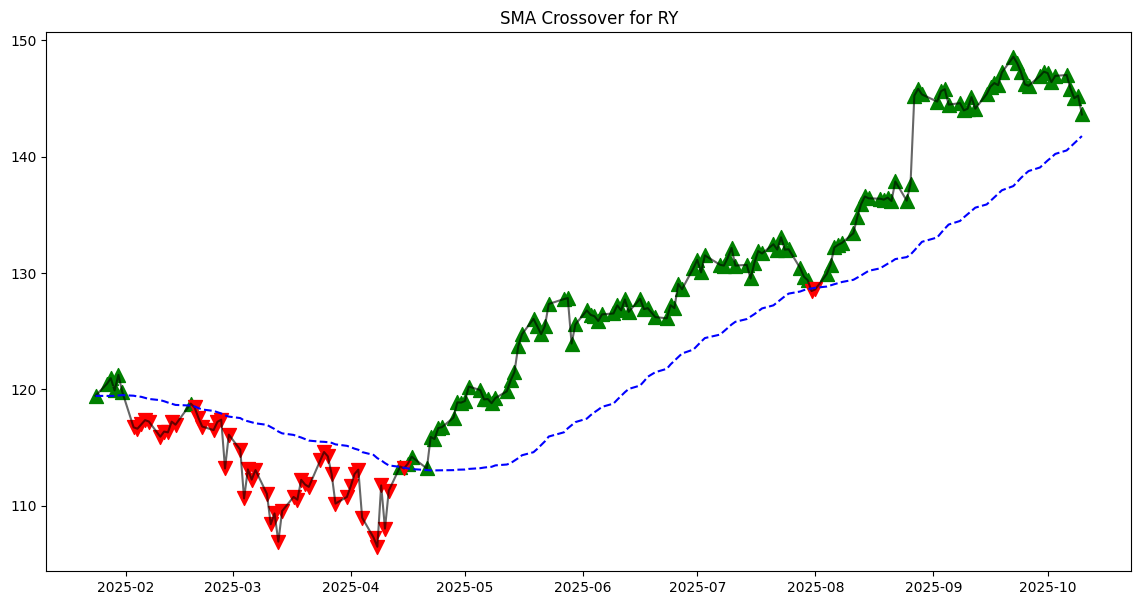

In [7]:
plot_object = Plot(strategy.df)
plot_object.plot_short_time(strategy_name='momentum', ticker='RY', time=180, plot_signals=True)

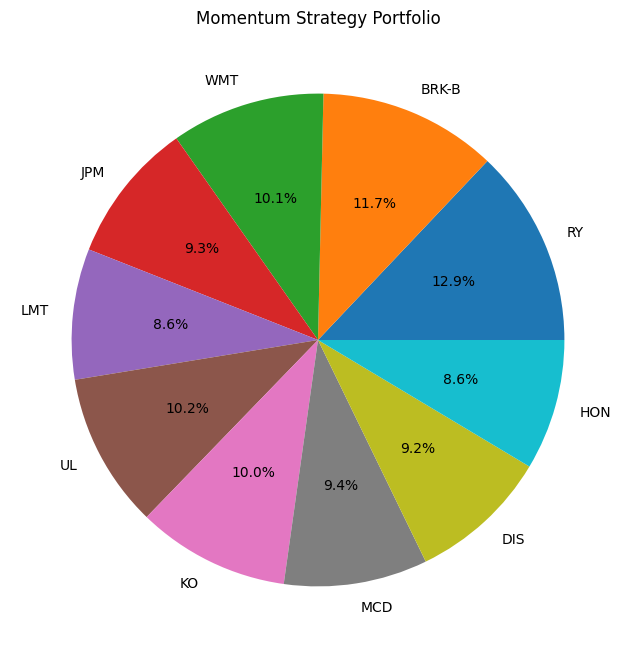

In [8]:
# plt.figure(figsize=(8, 8))
# plt.pie(momentum_portfolio['Value'], labels=momentum_portfolio['Ticker'], autopct='%1.1f%%')
# plt.title('Momentum Strategy Portfolio')
# plt.show()
plot_object = Plot(strategy.df)
plot_object.plot_porfolio(momentum_portfolio, name='Momentum Strategy Portfolio')

## **3.2. Mean Reversion Strategy**

In [9]:
from trading_strategy import TradingStrategy
from plot import Plot

In [10]:
print(set(strategy.df.columns.get_level_values(0)))

{'Signal', 'SMA_200', 'Log Return', 'Adj Close', 'SMA_50', 'High', 'Position Size', 'Close', 'Open', 'Volume', 'Volatility', 'Low'}


In [11]:
strategy.mean_reversion_signal()
strategy.apply_position_sizing()

d:\CODE\PYTHON\CF\trading_strategy.py:88: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  self.df = self.df.drop(columns=['Position Size'])


In [12]:
strategy.get_actions().sort_values(by=['Value_Est'], ascending=False).head(10)

Ngày giao dịch: 2025-10-10


,Ticker,Action,Shares,Price_Est,Value_Est
3,HON,BUY,40,191.342178,7653.687134
2,HD,BUY,19,375.262878,7129.994690
9,PEP,SELL,44,144.710007,6367.240295
8,NOC,BUY,10,632.446655,6324.466553
5,LIN,BUY,13,456.478851,5934.225067
4,HSBC,BUY,86,66.862495,5750.174606
16,YUM,BUY,36,142.017471,5112.628967
14,UNH,BUY,13,367.690002,4779.970032
13,SLB,BUY,124,32.870319,4075.919601
1,BA,BUY,18,216.000000,3888.000000


In [18]:
# Get top long portfolio
top_long, top_short = strategy.get_top_portfolio(top_n=10)
top_long

Ngày giao dịch: 2025-10-10


ValueError: too many values to unpack (expected 2)

In [37]:
mean_reversion_portfolio = strategy.get_top_portfolio(top_n=10)
mean_reversion_portfolio

Ngày giao dịch: 2025-10-10


,Ticker,Price,Volatility,Action,Shares,Value
0,MCD,295.238342,0.121438,LONG,28,8266.673584
1,HON,188.231689,0.120601,LONG,40,7529.267578
2,HD,373.335358,0.097521,LONG,19,7093.371796
3,LIN,452.154755,0.143472,LONG,13,5878.011810
4,HSBC,65.462288,0.184892,LONG,86,5629.756760
5,ADSK,303.500000,0.184758,LONG,18,5463.000000
6,YUM,140.952499,0.173572,LONG,36,5074.289978
7,SBUX,77.897240,0.222882,LONG,58,4518.039902
8,SLB,31.471369,0.266056,LONG,124,3902.449730
9,PEP,150.080002,0.162101,SHORT,-44,6603.520081


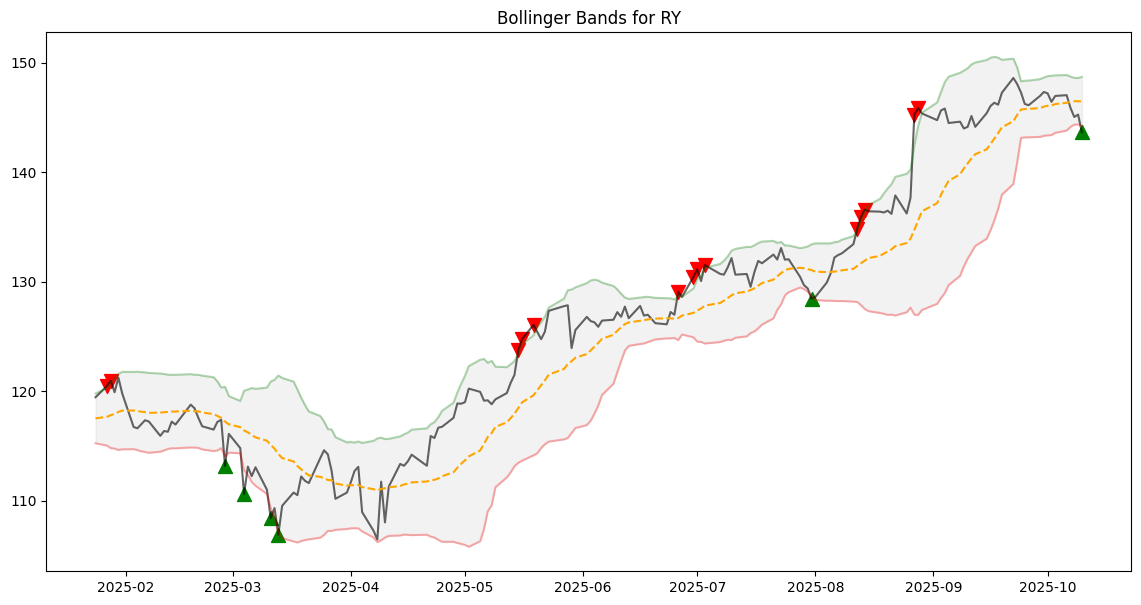

In [13]:
plot_object = Plot(strategy.df)
plot_object.plot_short_time(strategy_name='mean_reversion', ticker='RY', time=180, plot_signals=True)

In [ ]:
print(set(strategy.df.columns.get_level_values(0)))

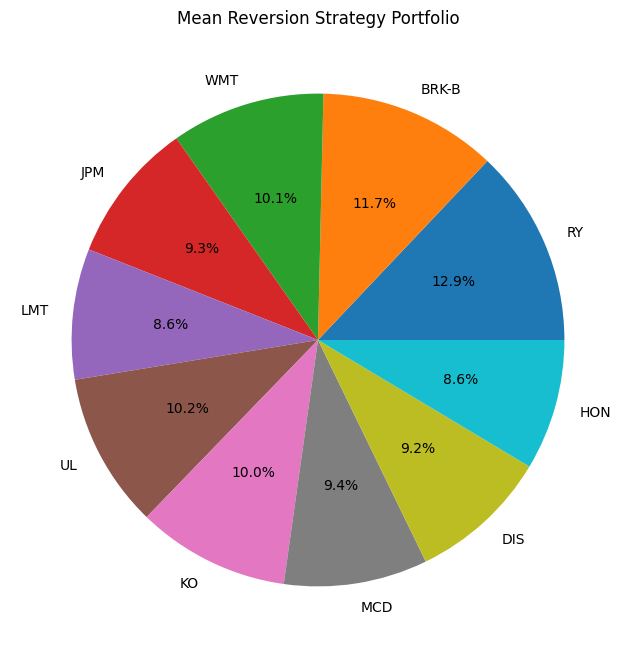

In [17]:
plt.figure(figsize=(8, 8))
plt.pie(momentum_portfolio['Value'], labels=momentum_portfolio['Ticker'], autopct='%1.1f%%')
plt.title("Mean Reversion Strategy Portfolio")
plt.show()